# ETF 动量 + R² 策略参数扫描回测

**策略逻辑：**
- 每隔 `rebal_period` 个交易日做一次调仓
- 调仓时，对每只 ETF 取过去 `n` 天的 log(收盘价)，做线性回归 log(P) = a + b·t
- 用 **斜率 b** 衡量动量强度，用 **R²** 衡量趋势质量
- 仅保留 R² ≥ 阈值的标的，从中选斜率最大的 top_k 只等权持有
- 若无标的通过筛选，该期空仓（收益为 0）

**扫描维度：** n (回看天数) × R² 阈值 × 调仓周期

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings('ignore')

DB_DIR = Path('db')

## 1. 加载数据

In [2]:
closes = {}
for fp in sorted(DB_DIR.glob('*.csv')):
    df = pd.read_csv(fp, index_col=0, parse_dates=True)
    if not df.empty and 'Close' in df.columns and len(df) >= 30:
        closes[fp.stem] = df['Close']

# ffill 填充交易日间隙（ETF 上市前仍为 NaN，不会被错误填充）
panel = pd.DataFrame(closes).sort_index().ffill()
print(f'加载 {panel.shape[1]} 只 ETF，{panel.shape[0]} 个交易日')
print(f'日期范围: {panel.index[0].strftime("%Y-%m-%d")} ~ {panel.index[-1].strftime("%Y-%m-%d")}')

加载 175 只 ETF，2917 个交易日
日期范围: 2014-03-05 ~ 2026-03-06


## 2. 回测引擎

利用滚动窗口向量化计算线性回归的斜率和 R²，避免逐只逐日循环。

In [3]:
def rolling_linreg(log_close: pd.DataFrame, n: int):
    """对 log(close) 面板做滚动 n 日线性回归，返回 slope 和 R² 面板。

    x = 0, 1, ..., n-1（固定），y = log(close) 滚动窗口。
    利用解析公式一次性算出全部日期 × 全部 ETF 的 slope / R²。
    """
    sum_x = n * (n - 1) / 2
    sum_x2 = n * (n - 1) * (2 * n - 1) / 6
    denom_x = n * sum_x2 - sum_x ** 2

    weights = np.arange(n, dtype=float)

    roll_sum_y = log_close.rolling(n).sum()
    roll_sum_y2 = (log_close ** 2).rolling(n).sum()
    roll_sum_xy = log_close.rolling(n).apply(lambda w: np.dot(weights, w), raw=True)

    slope = (n * roll_sum_xy - sum_x * roll_sum_y) / denom_x

    ss_tot = n * roll_sum_y2 - roll_sum_y ** 2
    ss_reg = (n * roll_sum_xy - sum_x * roll_sum_y) ** 2 / denom_x
    r2 = ss_reg / ss_tot.replace(0, np.nan)
    r2 = r2.clip(0, 1)

    return slope, r2


# 预计算中间量（后续回测复用）
log_close = np.log(panel.replace(0, np.nan))
daily_ret = panel.pct_change()
linreg_cache = {}

def precompute_linreg(n_list):
    """对所有 n 值预计算 slope / R²，缓存到 linreg_cache。"""
    for n in n_list:
        if n not in linreg_cache:
            linreg_cache[n] = rolling_linreg(log_close, n)
            print(f'  预计算 rolling_linreg(n={n}) 完成')


def backtest_momentum(
    slope: pd.DataFrame,
    r2: pd.DataFrame,
    daily_ret: pd.DataFrame,
    n: int,
    r2_threshold: float,
    rebal_period: int,
    top_k: int = 1,
) -> pd.Series:
    """基于预计算的 slope/R² 运行回测，返回每日净值序列。"""
    start_idx = n + 5
    dates = daily_ret.index[start_idx:]

    rebal_indices = list(range(0, len(dates), rebal_period))
    holdings = []

    for i, idx_pos in enumerate(rebal_indices):
        date = dates[idx_pos]
        s = slope.loc[date].dropna()
        r = r2.loc[date].dropna()
        common = s.index.intersection(r.index)
        s, r = s[common], r[common]

        candidates = s[r >= r2_threshold].sort_values(ascending=False)
        selected = candidates.head(top_k).index.tolist() if len(candidates) >= 1 else []

        next_pos = rebal_indices[i + 1] if i + 1 < len(rebal_indices) else len(dates)
        holdings.append((idx_pos, next_pos, selected))

    cum = 1.0
    nav_values = np.ones(len(dates))

    for start_pos, end_pos, selected in holdings:
        for d in range(start_pos, end_pos):
            date = dates[d]
            if selected and date in daily_ret.index:
                ret = daily_ret.loc[date, selected].mean()
                if np.isnan(ret):
                    ret = 0.0
            else:
                ret = 0.0
            cum *= (1 + ret)
            nav_values[d] = cum

    return pd.Series(nav_values, index=dates, name='NAV')

## 3. 定义参数网格

In [4]:
N_LIST = [5, 10, 15, 20, 22, 25, 30, 40]      # 动量回看天数
R2_LIST = [0.5, 0.6, 0.7, 0.8, 0.9]          # R² 阈值
REBAL_LIST = [5, 10, 15, 20]                  # 调仓周期（交易日）
TOP_K_LIST = [1, 3, 5]                        # 每次持有 ETF 数量（网格）

param_grid = list(product(N_LIST, R2_LIST, REBAL_LIST, TOP_K_LIST))
print(f'参数组合数: {len(param_grid)}')

参数组合数: 480


## 4. 批量回测

In [6]:
import time as _time

# 预计算所有 n 值的 slope / R²（最耗时的步骤，每个 n 只算一次）
print('预计算 rolling linreg ...')
precompute_linreg(N_LIST)

results = []
nav_cache = {}
t0 = _time.time()

for i, (n, r2_thresh, rebal, top_k) in enumerate(param_grid):
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}'
    if (i + 1) % 20 == 0 or i == 0:
        print(f'  进度: {i+1}/{len(param_grid)} — {label}')

    slope, r2 = linreg_cache[n]
    nav = backtest_momentum(slope, r2, daily_ret, n=n, r2_threshold=r2_thresh,
                            rebal_period=rebal, top_k=top_k)
    nav_cache[label] = nav

    # 按自然年切分，计算每年收益率
    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan

    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    row['annualized'] = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    row['total_ret'] = total_ret
    row['max_drawdown'] = ((nav / nav.cummax()) - 1).min()
    results.append(row)

elapsed = _time.time() - t0
print(f'\n回测完成，共 {len(results)} 组参数，耗时 {elapsed:.1f}s')

预计算 rolling linreg ...
  进度: 1/480 — n=5_R2=0.5_rebal=5_topk=1
  进度: 20/480 — n=5_R2=0.6_rebal=15_topk=3
  进度: 40/480 — n=5_R2=0.8_rebal=10_topk=1
  进度: 60/480 — n=5_R2=0.9_rebal=20_topk=5
  进度: 80/480 — n=10_R2=0.6_rebal=15_topk=3
  进度: 100/480 — n=10_R2=0.8_rebal=10_topk=1
  进度: 120/480 — n=10_R2=0.9_rebal=20_topk=5
  进度: 140/480 — n=15_R2=0.6_rebal=15_topk=3
  进度: 160/480 — n=15_R2=0.8_rebal=10_topk=1
  进度: 180/480 — n=15_R2=0.9_rebal=20_topk=5
  进度: 200/480 — n=20_R2=0.6_rebal=15_topk=3
  进度: 220/480 — n=20_R2=0.8_rebal=10_topk=1
  进度: 240/480 — n=20_R2=0.9_rebal=20_topk=5
  进度: 260/480 — n=22_R2=0.6_rebal=15_topk=3
  进度: 280/480 — n=22_R2=0.8_rebal=10_topk=1
  进度: 300/480 — n=22_R2=0.9_rebal=20_topk=5
  进度: 320/480 — n=25_R2=0.6_rebal=15_topk=3
  进度: 340/480 — n=25_R2=0.8_rebal=10_topk=1
  进度: 360/480 — n=25_R2=0.9_rebal=20_topk=5
  进度: 380/480 — n=30_R2=0.6_rebal=15_topk=3
  进度: 400/480 — n=30_R2=0.8_rebal=10_topk=1
  进度: 420/480 — n=30_R2=0.9_rebal=20_topk=5
  进度: 440/480 — n=40

## 5. 结果总览

In [17]:
result_df = pd.DataFrame(results)
result_df.to_csv('backtest_result.csv', index=False, encoding='utf-8-sig')

year_cols = [c for c in result_df.columns if isinstance(c, (int, np.integer))]
fmt_cols = year_cols + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']

display_df = result_df.copy()
for c in fmt_cols:
    if c in display_df.columns:
        display_df[c] = display_df[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

display_df = display_df.sort_values('annualized', ascending=False, key=lambda s: result_df['annualized'])

print('所有参数组合回测结果（按年化收益排序）:')
display(display_df.head(30))

所有参数组合回测结果（按年化收益排序）:


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,...,2021,2022,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
12,5,0.6,5,1,104.02%,4.24%,37.67%,29.24%,21.99%,107.71%,...,124.37%,23.60%,98.54%,54.98%,42.14%,-23.35%,68.35%,61.56%,30983.63%,-32.84%
0,5,0.5,5,1,95.05%,-10.42%,29.80%,31.56%,14.13%,108.46%,...,108.76%,27.57%,144.21%,58.62%,54.51%,-26.05%,70.64%,61.33%,30460.88%,-76.68%
1,5,0.5,5,3,66.53%,-14.33%,17.64%,104.34%,-0.82%,43.34%,...,83.49%,19.05%,92.68%,85.18%,80.70%,2.10%,56.60%,53.75%,17086.22%,-45.94%
24,5,0.7,5,1,86.77%,14.05%,7.83%,18.69%,33.21%,90.22%,...,109.46%,-1.25%,102.56%,34.72%,88.08%,-5.45%,55.42%,53.16%,16315.65%,-29.77%
36,5,0.8,5,1,78.92%,13.51%,4.90%,30.81%,20.50%,51.66%,...,99.70%,-9.61%,92.44%,64.02%,43.26%,-6.79%,48.66%,46.71%,9710.85%,-30.45%
3,5,0.5,10,1,63.86%,29.65%,21.71%,13.55%,-2.93%,99.71%,...,31.81%,35.93%,35.14%,63.45%,41.83%,20.33%,43.41%,46.01%,9164.02%,-44.27%
13,5,0.6,5,3,57.29%,24.98%,13.97%,36.08%,-6.01%,76.04%,...,83.89%,13.68%,69.10%,38.87%,59.15%,2.37%,45.71%,45.55%,8817.68%,-25.99%
15,5,0.6,10,1,51.06%,22.51%,22.21%,11.34%,9.19%,100.64%,...,51.83%,30.42%,15.95%,63.45%,44.12%,20.33%,43.87%,45.37%,8687.22%,-42.45%
2,5,0.5,5,5,57.77%,-5.46%,11.08%,73.57%,-6.35%,35.13%,...,85.68%,12.14%,54.01%,70.95%,73.73%,8.49%,44.57%,44.33%,7963.72%,-43.70%
130,15,0.5,20,3,50.23%,14.10%,19.06%,70.91%,-18.35%,40.23%,...,376.51%,-2.23%,17.09%,67.11%,20.12%,37.69%,55.71%,41.82%,6351.40%,-52.22%


## 6. 最优参数组合 Top 10

In [12]:
top10 = result_df.nlargest(10, 'annualized')[['n', 'R2_threshold', 'rebal_period', 'top_k'] + year_cols + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']].copy()
for c in fmt_cols:
    if c in top10.columns:
        top10[c] = top10[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')
top10.index = range(1, len(top10) + 1)
top10.index.name = '排名'
print('年化收益 Top 10 参数组合:')
display(top10)

年化收益 Top 10 参数组合:


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,...,2021,2022,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
排名,,,,,,,,,,,,,,,,,,,,,
1,5,0.6,5,1,104.02%,4.24%,37.67%,29.24%,21.99%,107.71%,...,124.37%,23.60%,98.54%,54.98%,42.14%,-23.35%,68.35%,61.56%,30983.63%,-32.84%
2,5,0.5,5,1,95.05%,-10.42%,29.80%,31.56%,14.13%,108.46%,...,108.76%,27.57%,144.21%,58.62%,54.51%,-26.05%,70.64%,61.33%,30460.88%,-76.68%
3,5,0.5,5,3,66.53%,-14.33%,17.64%,104.34%,-0.82%,43.34%,...,83.49%,19.05%,92.68%,85.18%,80.70%,2.10%,56.60%,53.75%,17086.22%,-45.94%
4,5,0.7,5,1,86.77%,14.05%,7.83%,18.69%,33.21%,90.22%,...,109.46%,-1.25%,102.56%,34.72%,88.08%,-5.45%,55.42%,53.16%,16315.65%,-29.77%
5,5,0.8,5,1,78.92%,13.51%,4.90%,30.81%,20.50%,51.66%,...,99.70%,-9.61%,92.44%,64.02%,43.26%,-6.79%,48.66%,46.71%,9710.85%,-30.45%
6,5,0.5,10,1,63.86%,29.65%,21.71%,13.55%,-2.93%,99.71%,...,31.81%,35.93%,35.14%,63.45%,41.83%,20.33%,43.41%,46.01%,9164.02%,-44.27%
7,5,0.6,5,3,57.29%,24.98%,13.97%,36.08%,-6.01%,76.04%,...,83.89%,13.68%,69.10%,38.87%,59.15%,2.37%,45.71%,45.55%,8817.68%,-25.99%
8,5,0.6,10,1,51.06%,22.51%,22.21%,11.34%,9.19%,100.64%,...,51.83%,30.42%,15.95%,63.45%,44.12%,20.33%,43.87%,45.37%,8687.22%,-42.45%
9,5,0.5,5,5,57.77%,-5.46%,11.08%,73.57%,-6.35%,35.13%,...,85.68%,12.14%,54.01%,70.95%,73.73%,8.49%,44.57%,44.33%,7963.72%,-43.70%


## 7. 热力图分析

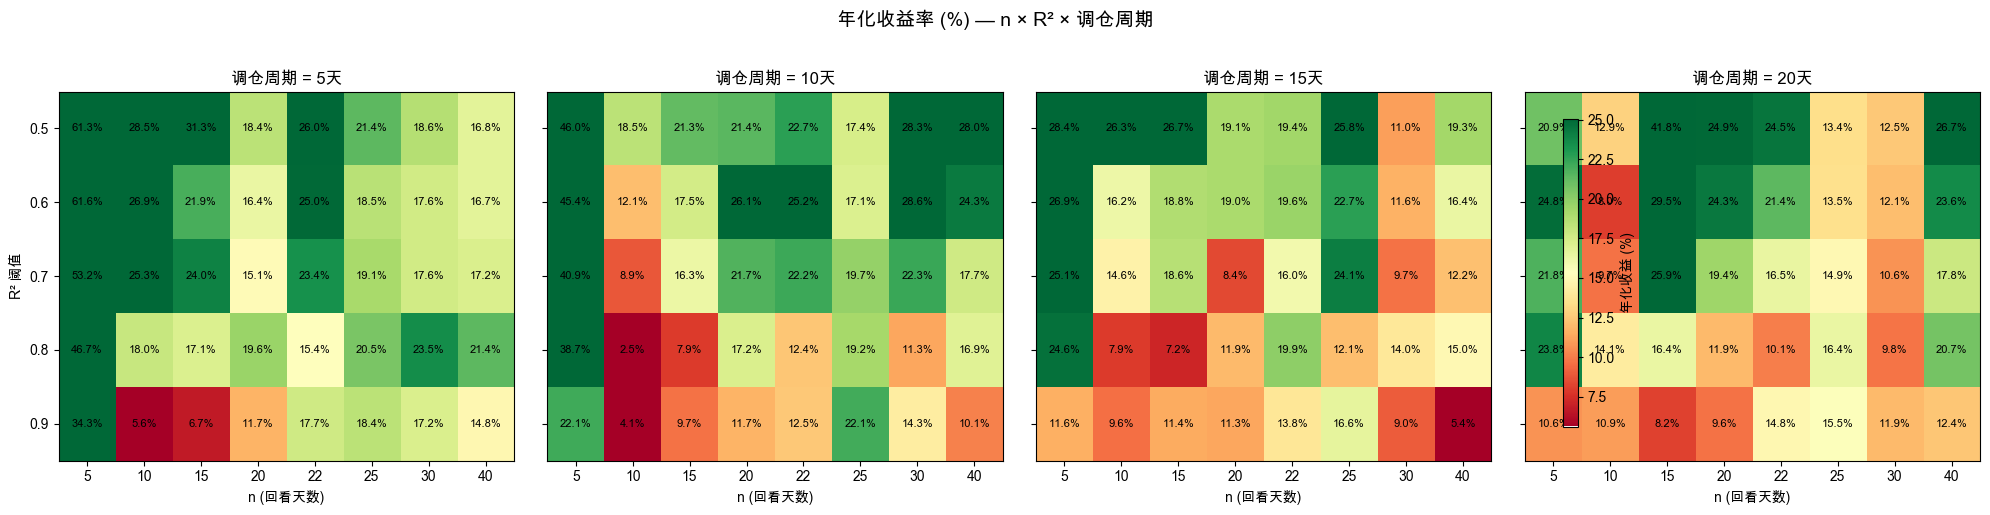

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Heiti TC']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, len(REBAL_LIST), figsize=(5 * len(REBAL_LIST), 5), sharey=True)
if len(REBAL_LIST) == 1:
    axes = [axes]

for ax, rebal in zip(axes, REBAL_LIST):
    subset = result_df[result_df['rebal_period'] == rebal]
    # 每个 (R2_threshold, n) 有多个 top_k，取年化最大后再 pivot
    agg = subset.groupby(['R2_threshold', 'n'], as_index=False)['annualized'].max()
    pivot = agg.pivot(index='R2_threshold', columns='n', values='annualized') * 100
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                   vmin=result_df['annualized'].quantile(0.1) * 100,
                   vmax=result_df['annualized'].quantile(0.9) * 100)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{v:.1f}' for v in pivot.index])
    ax.set_xlabel('n (回看天数)')
    if rebal == REBAL_LIST[0]:
        ax.set_ylabel('R² 阈值')
    ax.set_title(f'调仓周期 = {rebal}天')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=8)

fig.suptitle('年化收益率 (%) — n × R² × 调仓周期', fontsize=14, y=1.02)
fig.colorbar(im, ax=axes, label='年化收益 (%)', shrink=0.8)
plt.tight_layout()
plt.show()

## 8. 最优 & 基准净值曲线

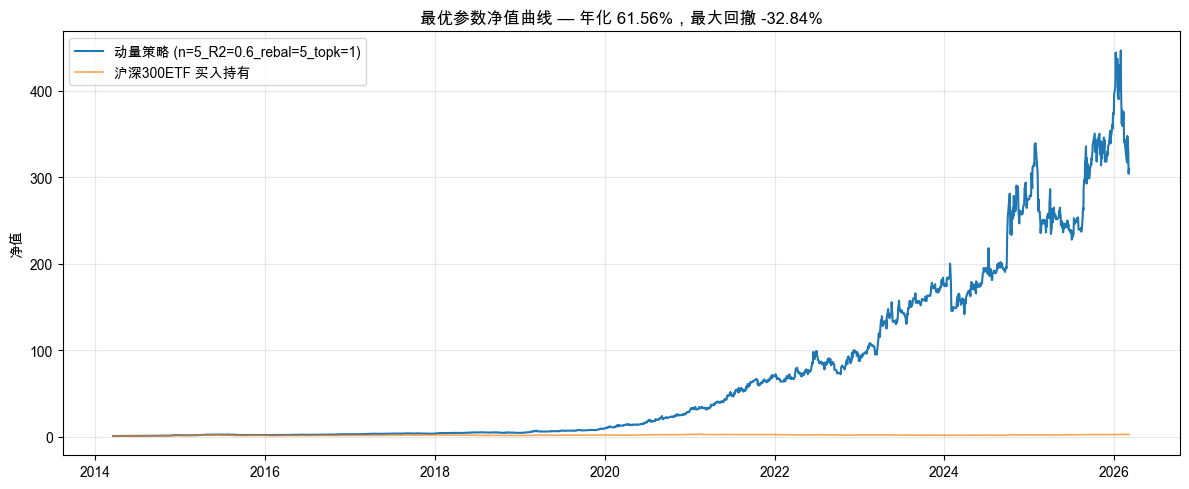

最优参数: n=5, R²≥0.6, 调仓周期=5天, top_k=1
年化收益: 61.56%
累计收益: 30983.63%
最大回撤: -32.84%


In [14]:
best_row = result_df.nlargest(1, 'annualized').iloc[0]
best_label = f"n={int(best_row['n'])}_R2={best_row['R2_threshold']}_rebal={int(best_row['rebal_period'])}_topk={int(best_row['top_k'])}"
best_nav = nav_cache[best_label]

# 基准：沪深300 ETF (SH510300) 买入持有
bench_sym = 'SH510300'
if bench_sym in panel.columns:
    bench = panel[bench_sym].reindex(best_nav.index).ffill()
    bench_nav = bench / bench.iloc[0]
else:
    bench_nav = None

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(best_nav.index, best_nav.values, label=f'动量策略 ({best_label})', linewidth=1.5)
if bench_nav is not None:
    ax.plot(bench_nav.index, bench_nav.values, label='沪深300ETF 买入持有', linewidth=1.2, alpha=0.7)
ax.set_ylabel('净值')
ax.set_title(f'最优参数净值曲线 — 年化 {best_row["annualized"]:.2%}，最大回撤 {best_row["max_drawdown"]:.2%}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'最优参数: n={int(best_row["n"])}, R²≥{best_row["R2_threshold"]}, 调仓周期={int(best_row["rebal_period"])}天, top_k={int(best_row["top_k"])}')
print(f'年化收益: {best_row["annualized"]:.2%}')
print(f'累计收益: {best_row["total_ret"]:.2%}')
print(f'最大回撤: {best_row["max_drawdown"]:.2%}')

## 9. 按维度聚合分析

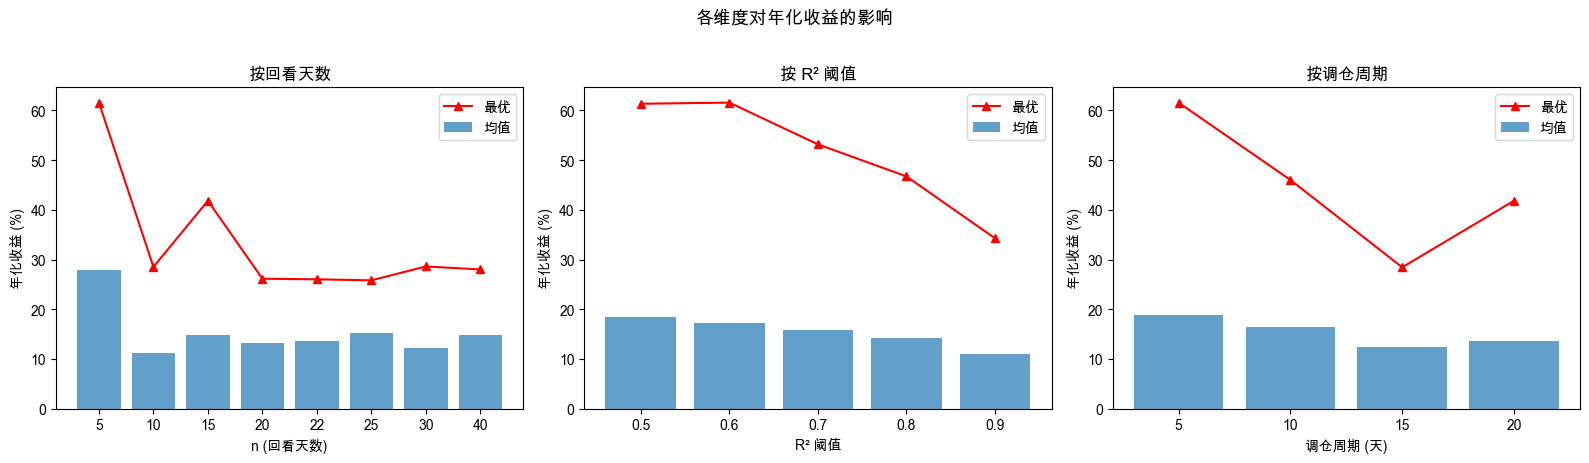

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 按 n 聚合
by_n = result_df.groupby('n')['annualized'].agg(['mean', 'max'])
axes[0].bar(by_n.index.astype(str), by_n['mean'] * 100, alpha=0.7, label='均值')
axes[0].plot(by_n.index.astype(str), by_n['max'] * 100, 'r^-', label='最优')
axes[0].set_xlabel('n (回看天数)')
axes[0].set_ylabel('年化收益 (%)')
axes[0].set_title('按回看天数')
axes[0].legend()

# 按 R² 聚合
by_r2 = result_df.groupby('R2_threshold')['annualized'].agg(['mean', 'max'])
axes[1].bar(by_r2.index.astype(str), by_r2['mean'] * 100, alpha=0.7, label='均值')
axes[1].plot(by_r2.index.astype(str), by_r2['max'] * 100, 'r^-', label='最优')
axes[1].set_xlabel('R² 阈值')
axes[1].set_ylabel('年化收益 (%)')
axes[1].set_title('按 R² 阈值')
axes[1].legend()

# 按调仓周期聚合
by_rebal = result_df.groupby('rebal_period')['annualized'].agg(['mean', 'max'])
axes[2].bar(by_rebal.index.astype(str), by_rebal['mean'] * 100, alpha=0.7, label='均值')
axes[2].plot(by_rebal.index.astype(str), by_rebal['max'] * 100, 'r^-', label='最优')
axes[2].set_xlabel('调仓周期 (天)')
axes[2].set_ylabel('年化收益 (%)')
axes[2].set_title('按调仓周期')
axes[2].legend()

fig.suptitle('各维度对年化收益的影响', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. 每年收益率详细对比

In [16]:
# 选出 Top5 参数，展示逐年收益率对比
top5 = result_df.nlargest(5, 'annualized')

year_data = []
for _, row in top5.iterrows():
    label = f"n={int(row['n'])},R²≥{row['R2_threshold']},T={int(row['rebal_period'])},top_k={int(row['top_k'])}"
    entry = {'参数': label}
    for yr in year_cols:
        entry[str(yr)] = row[yr]
    entry['完整年均值'] = row['avg_full_year']
    entry['年化'] = row['annualized']
    entry['最大回撤'] = row['max_drawdown']
    year_data.append(entry)

year_df = pd.DataFrame(year_data).set_index('参数')

styled = year_df.style.format('{:.2%}').background_gradient(
    cmap='RdYlGn', axis=None, subset=[c for c in year_df.columns if c != '最大回撤']
).background_gradient(
    cmap='RdYlGn_r', axis=None, subset=['最大回撤']
)
display(styled)

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,完整年均值,年化,最大回撤
参数,,,,,,,,,,,,,,,,
"n=5,R²≥0.6,T=5,top_k=1",104.02%,4.24%,37.67%,29.24%,21.99%,107.71%,207.41%,124.37%,23.60%,98.54%,54.98%,42.14%,-23.35%,68.35%,61.56%,-32.84%
"n=5,R²≥0.5,T=5,top_k=1",95.05%,-10.42%,29.80%,31.56%,14.13%,108.46%,209.88%,108.76%,27.57%,144.21%,58.62%,54.51%,-26.05%,70.64%,61.33%,-76.68%
"n=5,R²≥0.5,T=5,top_k=3",66.53%,-14.33%,17.64%,104.34%,-0.82%,43.34%,111.32%,83.49%,19.05%,92.68%,85.18%,80.70%,2.10%,56.60%,53.75%,-45.94%
"n=5,R²≥0.7,T=5,top_k=1",86.77%,14.05%,7.83%,18.69%,33.21%,90.22%,112.04%,109.46%,-1.25%,102.56%,34.72%,88.08%,-5.45%,55.42%,53.16%,-29.77%
"n=5,R²≥0.8,T=5,top_k=1",78.92%,13.51%,4.90%,30.81%,20.50%,51.66%,124.08%,99.70%,-9.61%,92.44%,64.02%,43.26%,-6.79%,48.66%,46.71%,-30.45%


## 11. 最优参数调仓明细（n=5, R²≥0.6, rebal=5, top_k=1）

In [21]:
import json as _json
with open('etf_all.json') as _f:
    _etf_data = _json.load(_f)
etf_name_map = {item['symbol']: item['name'] for item in _etf_data['data']['list']}

BEST_N, BEST_R2, BEST_REBAL, BEST_TOPK = 5, 0.6, 5, 1

slope, r2 = linreg_cache[BEST_N]
start_idx = BEST_N + 5
dates = daily_ret.index[start_idx:]
rebal_indices = list(range(0, len(dates), BEST_REBAL))

trades = []
cum = 1.0

for i, idx_pos in enumerate(rebal_indices):
    date = dates[idx_pos]
    s = slope.loc[date].dropna()
    r = r2.loc[date].dropna()
    common = s.index.intersection(r.index)
    s, r = s[common], r[common]

    candidates = s[r >= BEST_R2].sort_values(ascending=False)
    selected = candidates.head(BEST_TOPK).index.tolist() if len(candidates) >= 1 else []

    next_pos = rebal_indices[i + 1] if i + 1 < len(rebal_indices) else len(dates)
    hold_start = dates[idx_pos]
    hold_end = dates[min(next_pos, len(dates) - 1)]

    period_ret = 0.0
    for d in range(idx_pos, next_pos):
        dt = dates[d]
        if selected and dt in daily_ret.index:
            ret = daily_ret.loc[dt, selected].mean()
            if np.isnan(ret):
                ret = 0.0
        else:
            ret = 0.0
        cum *= (1 + ret)
        period_ret = (1 + period_ret) * (1 + ret) - 1

    sym = selected[0] if selected else '空仓'
    start_price = panel.loc[hold_start, sym] if sym != '空仓' else np.nan
    end_price = panel.loc[hold_end, sym] if sym != '空仓' else np.nan

    trades.append({
        '标的': sym,
        '名称': etf_name_map.get(sym, '-') if sym != '空仓' else '-',
        '开始日期': hold_start.strftime('%Y-%m-%d'),
        '开始价格': round(start_price, 4) if pd.notna(start_price) else '-',
        '结束日期': hold_end.strftime('%Y-%m-%d'),
        '结束价格': round(end_price, 4) if pd.notna(end_price) else '-',
        '本次收益': f'{period_ret:.2%}',
        '总净值': round(cum, 4),
    })

trade_df = pd.DataFrame(trades)
trade_df.to_csv('trade_detail.csv', index=False, encoding='utf-8-sig')
print(f'共 {len(trade_df)} 次调仓，已导出 trade_detail.csv')
display(trade_df)

共 582 次调仓，已导出 trade_detail.csv


,标的,名称,开始日期,开始价格,结束日期,结束价格,本次收益,总净值
0,SH510500,中证500ETF,2014-03-19,3.3254,2014-03-26,3.3434,-0.18%,0.9982
1,SH510900,恒生中国企业ETF易方达,2014-03-26,0.8299,2014-04-02,0.8437,3.59%,1.0340
2,SZ159920,恒生ETF,2014-04-02,0.9709,2014-04-10,0.9966,1.38%,1.0483
3,SH510230,金融ETF,2014-04-10,0.4947,2014-04-17,0.4755,-0.16%,1.0465
4,SH513500,标普500ETF博时,2014-04-17,0.5165,2014-04-24,0.522,1.56%,1.0629
...,...,...,...,...,...,...,...,...
577,SH517520,黄金股ETF,2026-01-28,3.095,2026-02-04,2.632,-6.25%,376.0956
578,SZ159326,电网设备ETF,2026-02-04,1.818,2026-02-11,1.81,-0.17%,375.4730
579,SH516620,影视ETF,2026-02-11,1.316,2026-02-26,1.163,-15.53%,317.1497
580,SH513310,中韩半导体ETF,2026-02-26,4.321,2026-03-05,4.099,-3.91%,304.7566


## 12. 当前应持仓标的（n=5, R²≥0.6, top_k=1）

In [22]:
latest_date = panel.index[-1]
s_now = slope.loc[latest_date].dropna()
r_now = r2.loc[latest_date].dropna()
common = s_now.index.intersection(r_now.index)
s_now, r_now = s_now[common], r_now[common]

candidates = s_now[r_now >= BEST_R2].sort_values(ascending=False)

print(f'策略参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, top_k={BEST_TOPK}')
print(f'信号日期: {latest_date.strftime("%Y-%m-%d")}')
print()

if len(candidates) >= 1:
    pick = candidates.head(BEST_TOPK)
    print('当前应持仓标的:')
    for sym, slp in pick.items():
        r2_val = r_now[sym]
        price = panel.loc[latest_date, sym]
        name = etf_name_map.get(sym, '')
        print(f'  {sym} {name}  斜率={slp:.6f}  R²={r2_val:.4f}  最新价={price:.4f}')
else:
    print('当前无标的通过筛选 → 空仓')

print()
print(f'所有通过 R²≥{BEST_R2} 筛选的候选标的 (共 {len(candidates)} 只):')
cand_df = pd.DataFrame({
    '标的': candidates.index,
    '名称': [etf_name_map.get(s, '') for s in candidates.index],
    '斜率': candidates.values,
    'R²': [r_now[s] for s in candidates.index],
    '最新价': [panel.loc[latest_date, s] for s in candidates.index],
}).reset_index(drop=True)
display(cand_df.head(20))

策略参数: n=5, R²≥0.6, rebal=5, top_k=1
信号日期: 2026-03-06

当前应持仓标的:
  SH511260 十年国债ETF  斜率=0.000124  R²=0.6325  最新价=135.2460

所有通过 R²≥0.6 筛选的候选标的 (共 42 只):


,标的,名称,斜率,R²,最新价
0,SH511260,十年国债ETF,0.000124,0.632494,135.246002
1,SH511030,公司债ETF,0.000100,0.764239,107.178001
2,SH511360,短融ETF海富通,0.000071,0.923260,113.133003
3,SH563760,全指自由现金流ETF,-0.002053,0.675453,1.359000
4,SZ159865,养殖ETF,-0.003656,0.723034,0.625000
5,SH515100,红利低波100ETF,-0.004017,0.722406,1.459000
6,SZ159928,消费ETF,-0.004333,0.916994,0.756000
7,SH510050,上证50ETF,-0.004786,0.622411,3.066000
8,SZ159545,恒生红利低波ETF易方达,-0.004995,0.644175,1.489000
9,SH560080,中药ETF,-0.005047,0.717569,1.021000


## 13. 近 3 年回测 Top 10 参数

In [23]:
import time as _time

panel_3y = panel.loc[panel.index >= panel.index[-1] - pd.DateOffset(years=3)]
log_close_3y = np.log(panel_3y.replace(0, np.nan))
daily_ret_3y = panel_3y.pct_change()

linreg_cache_3y = {}
for n in N_LIST:
    linreg_cache_3y[n] = rolling_linreg(log_close_3y, n)
print('近3年 rolling_linreg 预计算完成')

results_3y = []
t0 = _time.time()

for i, (n, r2_thresh, rebal, top_k) in enumerate(param_grid):
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}'
    if (i + 1) % 100 == 0 or i == 0:
        print(f'  进度: {i+1}/{len(param_grid)} — {label}')

    slope_3y, r2_3y = linreg_cache_3y[n]
    nav = backtest_momentum(slope_3y, r2_3y, daily_ret_3y, n=n,
                            r2_threshold=r2_thresh, rebal_period=rebal, top_k=top_k)

    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan

    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    row['annualized'] = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    row['total_ret'] = total_ret
    row['max_drawdown'] = ((nav / nav.cummax()) - 1).min()
    results_3y.append(row)

elapsed = _time.time() - t0
print(f'\n近3年回测完成，共 {len(results_3y)} 组参数，耗时 {elapsed:.1f}s')

result_3y_df = pd.DataFrame(results_3y)
year_cols_3y = [c for c in result_3y_df.columns if isinstance(c, (int, np.integer))]
fmt_cols_3y = year_cols_3y + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']

top10_3y = result_3y_df.nlargest(10, 'annualized')[
    ['n', 'R2_threshold', 'rebal_period', 'top_k'] + year_cols_3y +
    ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']
].copy()

for c in fmt_cols_3y:
    if c in top10_3y.columns:
        top10_3y[c] = top10_3y[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

result_3y_df.to_csv('backtest_result_3.csv', index=False, encoding='utf-8-sig')

print(f'\n近3年数据范围: {panel_3y.index[0].strftime("%Y-%m-%d")} ~ {panel_3y.index[-1].strftime("%Y-%m-%d")}')
print(f'已导出 backtest_result_3.csv（共 {len(result_3y_df)} 条）')
print('近3年回测 Top 10 参数组合:')
display(top10_3y)

近3年 rolling_linreg 预计算完成
  进度: 1/480 — n=5_R2=0.5_rebal=5_topk=1
  进度: 100/480 — n=10_R2=0.8_rebal=10_topk=1
  进度: 200/480 — n=20_R2=0.6_rebal=15_topk=3
  进度: 300/480 — n=22_R2=0.9_rebal=20_topk=5
  进度: 400/480 — n=30_R2=0.8_rebal=10_topk=1

近3年回测完成，共 480 组参数，耗时 26.5s

近3年数据范围: 2023-03-06 ~ 2026-03-06
已导出 backtest_result_3.csv（共 480 条）
近3年回测 Top 10 参数组合:


,n,R2_threshold,rebal_period,top_k,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
1,5,0.5,5,3,64.68%,85.18%,80.70%,2.10%,82.94%,81.48%,484.47%,-22.28%
93,10,0.7,20,1,64.29%,16.50%,126.67%,18.11%,71.59%,76.08%,428.66%,-27.11%
9,5,0.5,20,1,48.90%,19.67%,97.82%,46.73%,58.74%,74.50%,420.32%,-36.64%
81,10,0.6,20,1,50.67%,14.22%,121.41%,18.11%,67.81%,68.48%,364.28%,-27.11%
2,5,0.5,5,5,37.57%,70.95%,73.73%,8.49%,72.34%,67.12%,357.83%,-16.71%
37,5,0.8,5,3,41.32%,77.07%,64.95%,5.60%,71.01%,66.11%,349.63%,-18.94%
21,5,0.6,20,1,31.74%,19.67%,92.08%,46.73%,55.87%,65.78%,346.99%,-36.64%
411,30,0.9,10,1,12.56%,52.90%,93.95%,20.33%,73.43%,64.51%,316.01%,-14.90%
123,15,0.5,10,1,-20.79%,229.89%,48.09%,13.19%,138.99%,64.08%,325.40%,-53.79%
120,15,0.5,5,1,-19.78%,249.67%,98.28%,-25.85%,173.97%,63.51%,321.15%,-43.32%
